# Running Bifurcation Analysis on the 5.1 Coupling Toy Microbial Community

In [1]:
import gifba
import cobra as cb
from micom import Community
import matplotlib.pyplot as plt
from cobra import Model
import pandas as pd
import numpy as np
import optlang
import csv

In [33]:
# load models and media 
models, media = gifba.utils.load_simple_models("5_1_coupling") 

# bifurcation analysis
N_PTS = 200
N_ITERS = 10
LAG_PLOT = 4
abundances = np.linspace(0.01, 0.99, N_PTS) # avoid 0 and 1

# file to store results
csv_log_path = "data/5_1_coupling_bifurcation.csv"
with open(csv_log_path, "w", newline="") as f:
    w = csv.writer(f, delimiter="\t")
    w.writerow(["rel_abund_1", "period", "iter_converged", "EX_Bio(e) (1) fluxes"])

for pt in range(N_PTS):
    rel_abund = [abundances[pt], 1 - abundances[pt]]
    community = gifba.gifbaObject(models,
                                media, 
                                rel_abund)

    # run iterations
    media_flux, org_flux = community.run_gifba(iters=N_ITERS, 
                                            method="pfba", 
                                            v=False)
    if pt == 0:
        bifurc_param = []
        bifurc_state_bio = []

    vals = community.org_fluxes.loc[0, :]["EX_Bio(e)"].to_numpy().flatten()
    tail = vals[-LAG_PLOT:] if len(vals) >= LAG_PLOT else vals

    # parse bifurcation results to save
    period = community.periodicity if community.periodicity is not None else community.iters
    iter_converged = community.iter_converged if community.iter_converged is not None else community.iters

    # store results
    fmt = lambda a: ",".join(f"{x:.12f}" for x in a)
    with open(csv_log_path, "a") as f:
        w = csv.writer(f, delimiter="\t")
        w.writerow([
            rel_abund[0],
            period,
            iter_converged,
            fmt(tail)
        ])

Read LP format model from file /tmp/tmporgelkv3.lp
Reading time = 0.00 seconds
: 6 rows, 14 columns, 24 nonzeros
Read LP format model from file /tmp/tmprap7ne3o.lp
Reading time = 0.00 seconds
: 6 rows, 14 columns, 24 nonzeros


Read LP format model from file /tmp/tmp8qhnybsd.lp
Reading time = 0.00 seconds
: 6 rows, 14 columns, 24 nonzeros
Read LP format model from file /tmp/tmpwhho9n29.lp
Reading time = 0.00 seconds
: 6 rows, 14 columns, 24 nonzeros
Read LP format model from file /tmp/tmpv5drh2kg.lp
Reading time = 0.00 seconds
: 6 rows, 14 columns, 24 nonzeros
Read LP format model from file /tmp/tmpywpxm4xi.lp
Reading time = 0.00 seconds
: 6 rows, 14 columns, 24 nonzeros
Read LP format model from file /tmp/tmp2e20pln5.lp
Reading time = 0.00 seconds
: 6 rows, 14 columns, 24 nonzeros
Read LP format model from file /tmp/tmpekz7dyiw.lp
Reading time = 0.00 seconds
: 6 rows, 14 columns, 24 nonzeros
Read LP format model from file /tmp/tmp9rqa3y1r.lp
Reading time = 0.00 seconds
: 6 rows, 14 columns, 24 nonzeros
Read LP format model from file /tmp/tmpw9g9ehsh.lp
Reading time = 0.00 seconds
: 6 rows, 14 columns, 24 nonzeros
Read LP format model from file /tmp/tmp2zsosj4o.lp
Reading time = 0.00 seconds
: 6 rows, 14 colu

abundances shape: (200, 4)
bio_fluxes shape: (200, 4)
period shape: (200,)
iters_converged shape: (200,)


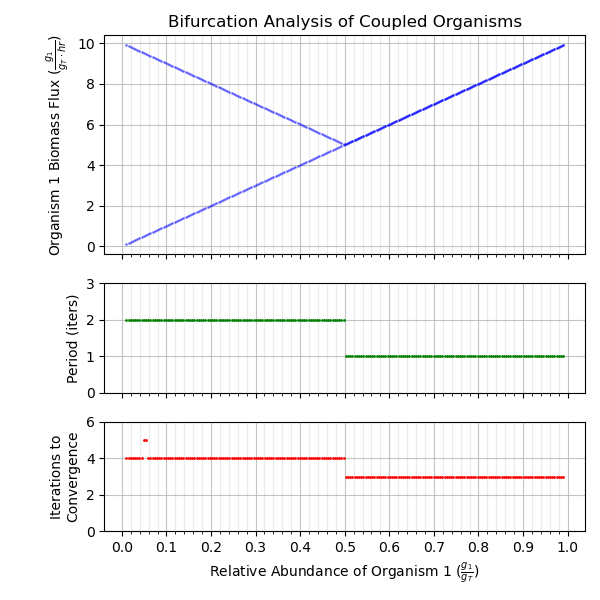

In [34]:
# turn of jupyter formating
%config InlineBackend.print_figure_kwargs = {'bbox_inches': None}

# load results
results_df = pd.read_csv(csv_log_path, delimiter="\t")
bio_fluxes = np.array([np.fromstring(s, sep=",") for s in results_df["EX_Bio(e) (1) fluxes"]])
period = results_df["period"].to_numpy()
iters_converged = results_df["iter_converged"].to_numpy()
abundances = results_df["rel_abund_1"].to_numpy()

abundances = np.hstack([abundances.reshape(-1, 1)] * bio_fluxes.shape[1])
print(f"abundances shape: {abundances.shape}")
print(f"bio_fluxes shape: {bio_fluxes.shape}")
print(f"period shape: {period.shape}")
print(f"iters_converged shape: {iters_converged.shape}")

# plot results
n_major_xticks = 10
n_minor_xticks = 5 * n_major_xticks
major_xticks = np.linspace(0, 1, n_major_xticks+1)
minor_xticks = np.linspace(0, 1, n_minor_xticks+1)

fig, axs = plt.subplots(
    nrows=3,
    ncols=1,
    figsize=(6, 6),
    clear=True,
    sharex=True,
    gridspec_kw={"height_ratios": [2, 1, 1]}
)

# bifurcation plot
axs[0].plot(abundances, bio_fluxes, "o", ms=1, alpha= 1/LAG_PLOT, color="b")
axs[0].set_ylabel(r"Organism 1 Biomass Flux ($\frac{g_1}{g_T \cdot hr}$)")
axs[0].set_title("Bifurcation Analysis of Coupled Organisms")
axs[0].set_xticks(major_xticks)
axs[0].set_xticks(minor_xticks, minor=True)
axs[0].grid(which="major", alpha=0.75)
axs[0].grid(which="minor", alpha=0.25)

# periodicity plot
axs[1].plot(abundances[:, 0], period, "o", ms=1, color="g")
axs[1].set_ylabel(r"Period (iters)")
axs[1].set_xticks(major_xticks)
axs[1].set_xticks(minor_xticks, minor=True)
axs[1].grid(which="major", alpha=0.75)
axs[1].grid(which="minor", alpha=0.25)
axs[1].set_ylim([0, max(period) + 1])

# iter to convergence plot
axs[2].plot(abundances[:, 0], iters_converged, "o", ms=1, color="r")
axs[2].set_ylabel("Iterations to\nConvergence")
axs[2].set_xlabel(r"Relative Abundance of Organism 1 ($\frac{g_1}{g_T}$)")
axs[2].set_xticks(major_xticks)
axs[2].set_xticks(minor_xticks, minor=True)
axs[2].grid(which="major", alpha=0.75)
axs[2].grid(which="minor", alpha=0.25)
axs[2].set_ylim([0, max(iters_converged) + 1])



plt.tight_layout(rect=[0.05, 0, 1, 1])
# plt.show()